# G4 Intersect Exploration

Descriptive statistics and visualisations for the `bedtools_intersect` output comparing g4Discovery motifs and rG4detector peaks.

## Research questions

1. Which tool identifies the most G4FS?

    rG4detector identifies a total of 45077 G4 signal peaks, and G4Discovery finds 25654

2. How is the agreement between both tools?
    
    2.1. What percentage of the total G4FS (union) is identified by both tools (intersection)

        - Total motifs captured by RG4D: 25654 / 56094 (45.73%)
        - Total motifs captured by G4D: 45077 / 56094 (80.36%)

    2.2. What percentage of the total G4FS is identified exclusively by one of the tools

        - G4D only motifs: 11017 / 25654 (42.94%)
        - RG4D only motifs: 30279 / 45077 (67.17%)

3. How is the agreement between both tools, when only looking at PC vs LNC transcripts?
    
    

## 1. Setup & Helpers

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from importlib import reload
import sys; sys.path.insert(0, "/mnt/cbib/LNClassifier/paper/secondrna/workflow/")
from utils import g4_analysis_lib as lib

SAMPLE = "gencode.v47"
os.chdir("/mnt/cbib/LNClassifier/paper/secondrna")
print("Imports OK")

Imports OK


## 2. Data Loading

In [ ]:
G4DISCOVERY_PATH = f"results/{SAMPLE}/g4discovery/{SAMPLE}.g4Discovery.transcripts.bed.gz"
INTERSECT_PATH   = f"results/{SAMPLE}/{SAMPLE}.g4Discovery.rG4detector.intersect.bed"
PEAKS_PATH       = f"results/{SAMPLE}/{SAMPLE}.rG4detector.peaks.bed"
CODING_ANN_PATH  = f"results/{SAMPLE}/{SAMPLE}.coding_annotation.tsv"
LENGTH_ANN_PATH  = f"results/{SAMPLE}/{SAMPLE}.transcript_lengths.tsv"

g4discovery = lib.load_g4discovery(G4DISCOVERY_PATH)
intersect   = lib.load_intersect(INTERSECT_PATH)
peaks       = lib.load_peaks(PEAKS_PATH)
coding_ann  = lib.load_coding_annotation(CODING_ANN_PATH)
length_ann  = lib.load_length_annotation(LENGTH_ANN_PATH)

print(f"g4discovery: {g4discovery.shape}  intersect: {intersect.shape}  peaks: {peaks.shape}")
print(f"coding_ann:  {coding_ann.shape}   length_ann: {length_ann.shape}")

g4discovery: (31128, 8)  intersect: (31280, 15)  peaks: (45077, 6)
coding_ann:  (111652, 2)   length_ann: (385659, 2)


In [ ]:
union_df = lib.build_union_df(intersect, peaks)
union_df = lib.annotate_union(union_df, coding_ann, length_ann)

assert "real"      in union_df.columns, "missing coding annotation"
assert "tx_len_nt" in union_df.columns, "missing length annotation"
assert set(union_df["type"].unique()) <= {"both", "G4D only", "RG4D only"}
print(f"union_df: {union_df.shape}  types: {union_df['type'].value_counts().to_dict()}")

/mnt/cbib/LNClassifier/paper/secondrna/workflow/utils/g4_analysis_lib.py:122: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  union["overlaps"] = union["overlaps"].fillna(False).astype(bool)


union_df: (61850, 19)  types: {'RG4D only': 30570, 'G4D only': 16773, 'both': 14507}


## 3. Analysis definitions

In [ ]:
subsets = lib.build_subsets(union_df)
for spec, sdf in subsets:
    print(f"{spec.label:40s}  {len(sdf):6,} motifs")
assert len(subsets) == 8

Union (all motifs)                        61,850 motifs
rG4D-only motifs                          30,570 motifs
G4D pqs≥30 & G4H≥1.0                      61,850 motifs
G4D pqs≥30 & G4H≥1.2                      59,737 motifs
G4D pqs≥30 & G4H≥1.5                      54,696 motifs
G4D pqs≥40 & G4H≥1.0                      59,333 motifs
G4D pqs≥40 & G4H≥1.2                      57,372 motifs
G4D pqs≥40 & G4H≥1.5                      53,114 motifs


In [ ]:
from IPython.display import display, Markdown
from matplotlib_venn import venn2


def run_subset_analysis(spec, sdf, coding_ann, length_ann):
    """Run all analysis sections for one subset; returns numeric results dict."""
    display(Markdown(f"---\n## Subset: {spec.label}\n`{len(sdf):,}` motifs"))

    # ── 3. Aggregate Statistics ──────────────────────────────────────────────
    display(Markdown("### 3. Aggregate Statistics"))
    agg = lib.compute_aggregate_stats(sdf)
    display(pd.DataFrame([agg]).T.rename(columns={0: "value"}))

    if agg["g4d_total"] > 0 and agg["rg4d_total"] > 0:
        fig, ax = plt.subplots(figsize=(5, 5))
        venn2(
            subsets=(agg["g4d_only"], agg["rg4d_only"], agg["both"]),
            set_labels=("g4Discovery", "rG4detector"),
            ax=ax,
        )
        ax.set_title(f"Tool overlap — {spec.label}")
        plt.tight_layout(); plt.show()

    # ── 4. Coding Breakdown ──────────────────────────────────────────────────
    display(Markdown("### 4. Coding Breakdown"))
    class_bk = lib.compute_coding_breakdown(sdf)
    if not class_bk.empty:
        display(
            class_bk.style.format({
                "Total motifs": "{:,}", "With rG4D overlap": "{:,}", "Overlap (%)": "{:.1f}"
            })
        )
        fig, ax = plt.subplots(figsize=(7, 4))
        x = np.arange(len(class_bk)); w = 0.35
        ax.bar(x - w/2, class_bk["Total motifs"],      w, label="Total",      color=["#1565C0", "#2E7D32"])
        ax.bar(x + w/2, class_bk["With rG4D overlap"], w, label="With rG4D",  color=["#42A5F5", "#66BB6A"])
        ax.set_xticks(x); ax.set_xticklabels(class_bk.index)
        ax.set_ylabel("Motifs"); ax.set_title(f"Coding breakdown — {spec.label}")
        ax.legend(); plt.tight_layout(); plt.show()

    # ── 5. Length & Position ─────────────────────────────────────────────────
    display(Markdown("### 5. Length & Position"))
    pos_start = "rg4d_start" if spec.name == "rg4d_only" else "start"
    pos_end   = "rg4d_end"   if spec.name == "rg4d_only" else "end"

    pos_sdf = sdf.dropna(subset=["tx_len_nt", "real"]).copy()
    pos_sdf = pos_sdf[pos_sdf[pos_start] >= 0]

    if not pos_sdf.empty:
        pos_sdf["relative_pos"] = (
            (pos_sdf[pos_start] + pos_sdf[pos_end]) / 2 / pos_sdf["tx_len_nt"]
        )
        pos_sdf = pos_sdf[pos_sdf["relative_pos"].between(0, 1)]
        pos_sdf["class"] = pos_sdf["real"].map({True: "Protein-coding", False: "Non-coding"})

        fig, ax = plt.subplots(figsize=(8, 4))
        for label, color in [("Protein-coding", "#1565C0"), ("Non-coding", "#2E7D32")]:
            vals = pos_sdf.loc[pos_sdf["class"] == label, "relative_pos"]
            if vals.nunique() > 1:
                sns.kdeplot(vals, ax=ax, label=label, color=color, fill=True, alpha=0.3)
        ax.set_xlabel("Relative position (0 = 5′, 1 = 3′)")
        ax.set_ylabel("Density")
        ax.set_title(f"Positional distribution — {spec.label}")
        ax.legend(); ax.set_xlim(0, 1); plt.tight_layout(); plt.show()
    else:
        print("  (position data unavailable for this subset)")

    # ── 6. Score Analysis ────────────────────────────────────────────────────
    display(Markdown("### 6. Score Analysis"))
    score_col = "rg4d_score" if spec.name == "rg4d_only" else "g4HunterScore"
    score_sdf = sdf[sdf[score_col] > 0].copy()

    if not score_sdf.empty and spec.name != "rg4d_only":
        score_sdf["Overlap"] = score_sdf["overlaps"].map(
            {True: "With rG4D overlap", False: "No rG4D overlap"}
        )
        fig, ax = plt.subplots(figsize=(7, 4))
        sns.violinplot(
            data=score_sdf, x="Overlap", y=score_col,
            hue="Overlap", ax=ax, inner="box", legend=False,
            order=["No rG4D overlap", "With rG4D overlap"],
        )
        ax.set_ylabel("G4Hunter score")
        ax.set_title(f"Score distribution — {spec.label}")
        plt.tight_layout(); plt.show()

    # ── 7. Statistical Tests ─────────────────────────────────────────────────
    # Exclude rG4D-only rows: stats are on G4D motifs; for the rg4d_only subset
    # (no G4D rows) fall back to testing on rG4D motifs instead.
    display(Markdown("### 7. Statistical Tests"))
    stats_sdf = sdf[sdf["type"] != "RG4D only"]
    if stats_sdf.empty:
        stats_sdf = sdf
    test_res = lib.run_statistical_tests(stats_sdf, coding_ann, length_ann)
    display(pd.DataFrame([test_res]).T.rename(columns={0: "value"}))

    return {
        "spec":           spec,
        "agg_stats":      agg,
        "class_breakdown": class_bk,
        "test_results":   test_res,
    }

## 4. Results

---
## Subset: Union (all motifs)
`61,850` motifs

### 3. Aggregate Statistics

,value
total,61850.000000
both,14507.000000
g4d_only,16773.000000
rg4d_only,30570.000000
g4d_total,31280.000000
rg4d_total,45077.000000
g4d_overlap_frac,0.463779
rg4d_overlap_frac,0.321827


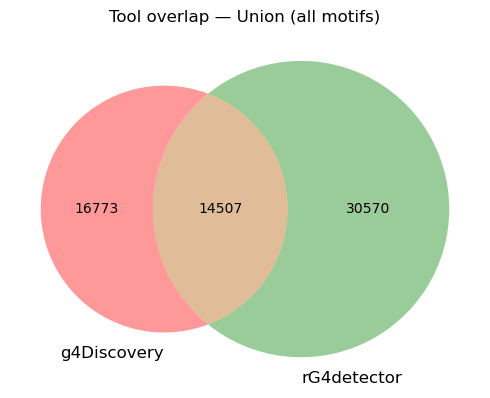

### 4. Coding Breakdown

,Total motifs,With rG4D overlap,Overlap (%)
real,,,
Non-coding,"6,507","1,560",24.0
Protein-coding,"19,733","5,230",26.5


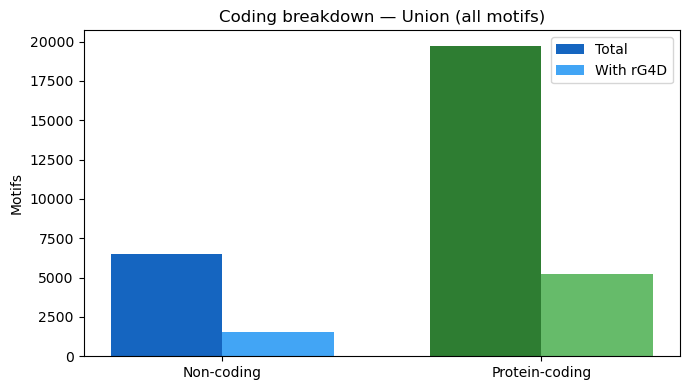

### 5. Length & Position

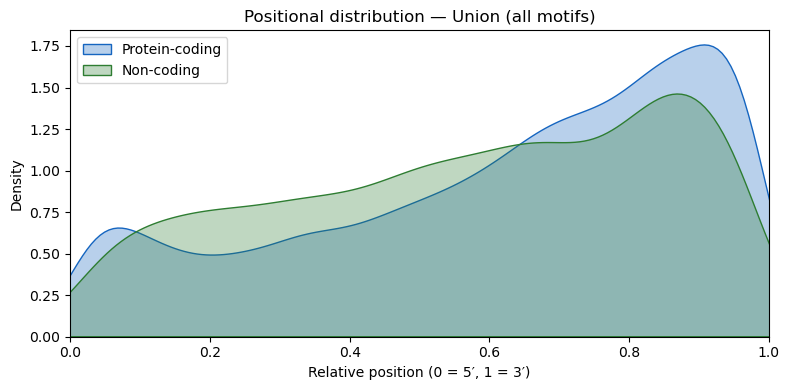

### 6. Score Analysis

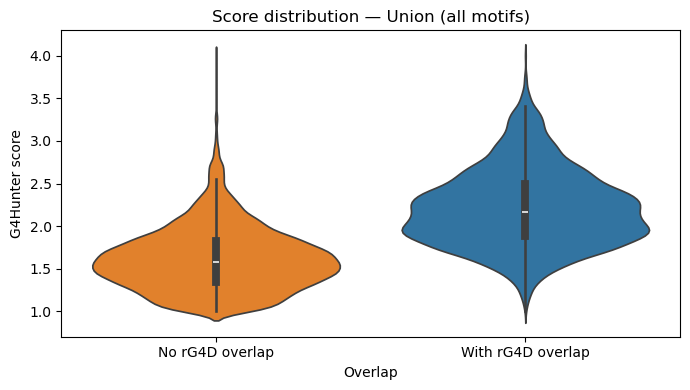

### 7. Statistical Tests

,value
chi2,1.258999e+03
p_chi2,9.191009e-276
cramers_v,1.061890e-01
u_stat,1.592724e+09
p_mwu,1.420159e-256
vda,5.299825e-01
median_coding_per_kb,0.000000e+00
median_lncrna_per_kb,0.000000e+00
n_coding,6.637600e+04
n_lncrna,4.527600e+04


---
## Subset: rG4D-only motifs
`30,570` motifs

### 3. Aggregate Statistics

,value
total,30570.0
both,0.0
g4d_only,0.0
rg4d_only,30570.0
g4d_total,0.0
rg4d_total,30570.0
g4d_overlap_frac,0.0
rg4d_overlap_frac,0.0


### 4. Coding Breakdown

,Total motifs,With rG4D overlap,Overlap (%)
real,,,
Non-coding,"3,245",0,0.0
Protein-coding,"7,851",0,0.0


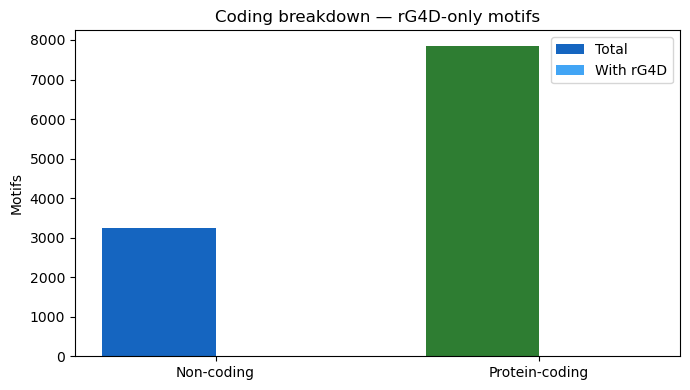

### 5. Length & Position

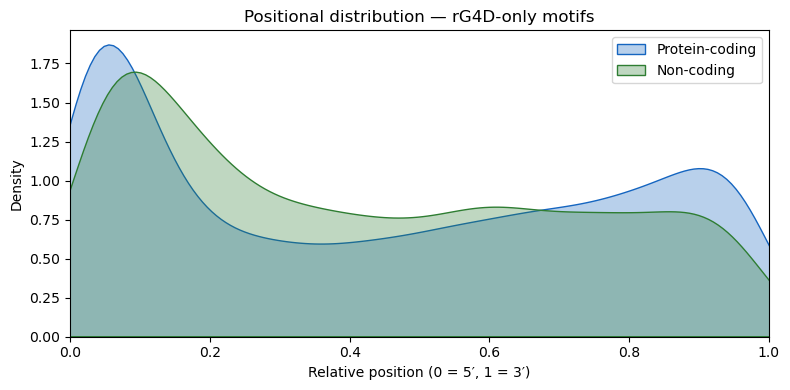

### 6. Score Analysis

### 7. Statistical Tests

,value
chi2,4.563876e+02
p_chi2,2.937778e-101
cramers_v,6.393426e-02
u_stat,1.553258e+09
p_mwu,3.707343e-89
vda,5.168501e-01
median_coding_per_kb,0.000000e+00
median_lncrna_per_kb,0.000000e+00
n_coding,6.637600e+04
n_lncrna,4.527600e+04


---
## Subset: G4D pqs≥30 & G4H≥1.0
`61,850` motifs

### 3. Aggregate Statistics

,value
total,61850.000000
both,14507.000000
g4d_only,16773.000000
rg4d_only,30570.000000
g4d_total,31280.000000
rg4d_total,45077.000000
g4d_overlap_frac,0.463779
rg4d_overlap_frac,0.321827


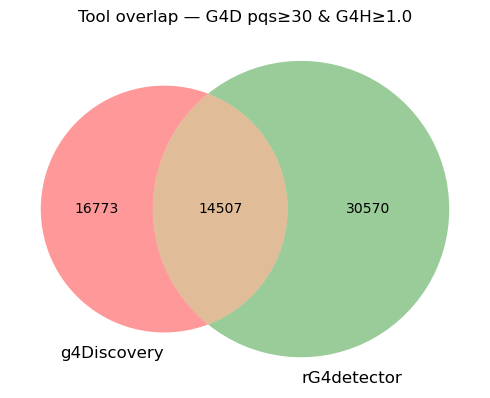

### 4. Coding Breakdown

,Total motifs,With rG4D overlap,Overlap (%)
real,,,
Non-coding,"6,507","1,560",24.0
Protein-coding,"19,733","5,230",26.5


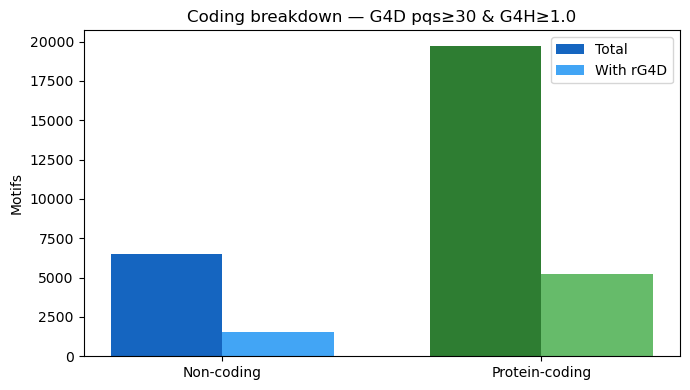

### 5. Length & Position

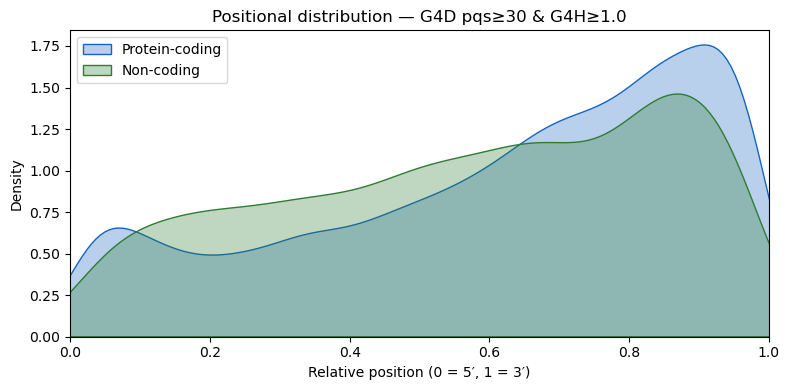

### 6. Score Analysis

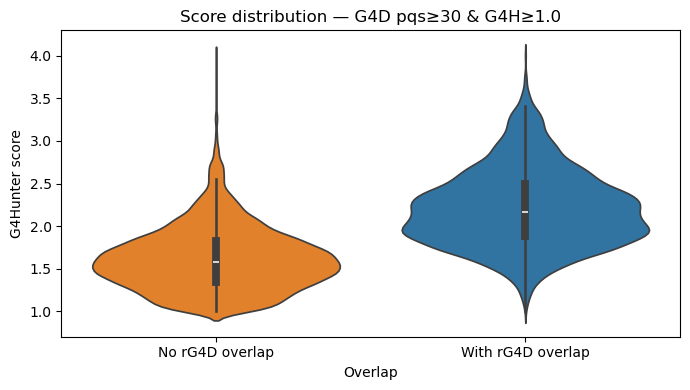

### 7. Statistical Tests

,value
chi2,1.258999e+03
p_chi2,9.191009e-276
cramers_v,1.061890e-01
u_stat,1.592724e+09
p_mwu,1.420159e-256
vda,5.299825e-01
median_coding_per_kb,0.000000e+00
median_lncrna_per_kb,0.000000e+00
n_coding,6.637600e+04
n_lncrna,4.527600e+04


---
## Subset: G4D pqs≥30 & G4H≥1.2
`59,737` motifs

### 3. Aggregate Statistics

,value
total,59737.000000
both,14459.000000
g4d_only,14708.000000
rg4d_only,30570.000000
g4d_total,29167.000000
rg4d_total,45029.000000
g4d_overlap_frac,0.495731
rg4d_overlap_frac,0.321104


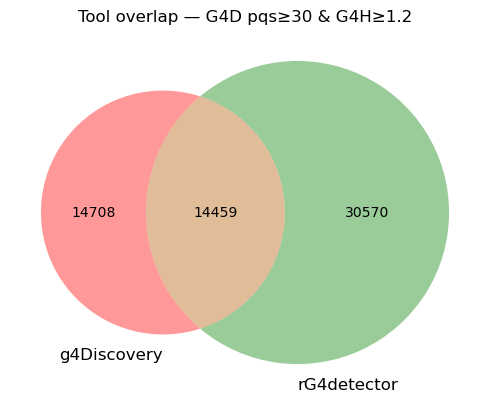

### 4. Coding Breakdown

,Total motifs,With rG4D overlap,Overlap (%)
real,,,
Non-coding,"6,328","1,559",24.6
Protein-coding,"18,827","5,207",27.7


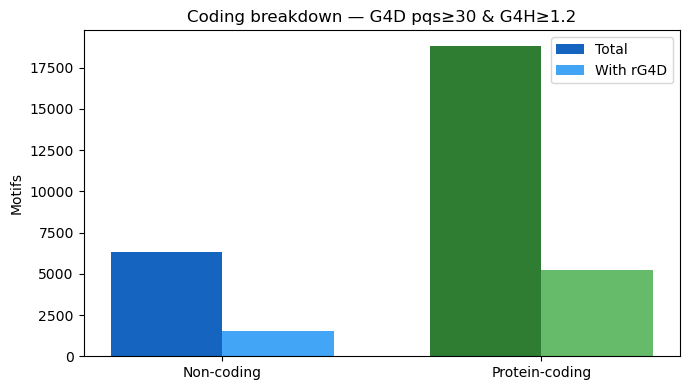

### 5. Length & Position

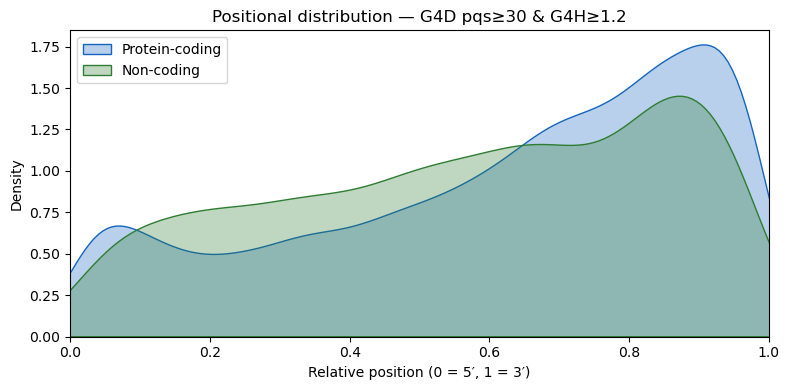

### 6. Score Analysis

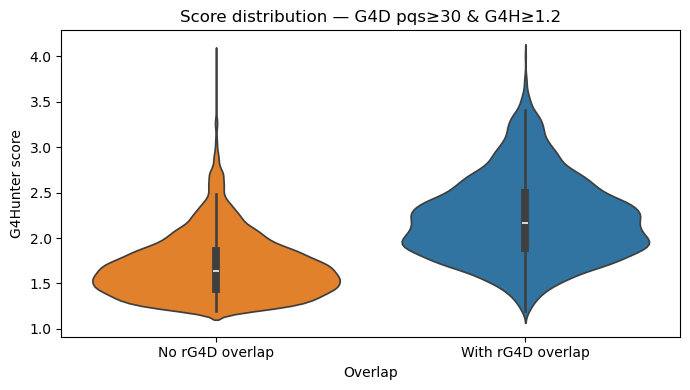

### 7. Statistical Tests

,value
chi2,1.171196e+03
p_chi2,1.109609e-256
cramers_v,1.024193e-01
u_stat,1.587689e+09
p_mwu,3.243023e-239
vda,5.283068e-01
median_coding_per_kb,0.000000e+00
median_lncrna_per_kb,0.000000e+00
n_coding,6.637600e+04
n_lncrna,4.527600e+04


---
## Subset: G4D pqs≥30 & G4H≥1.5
`54,696` motifs

### 3. Aggregate Statistics

,value
total,54696.000000
both,14021.000000
g4d_only,10105.000000
rg4d_only,30570.000000
g4d_total,24126.000000
rg4d_total,44591.000000
g4d_overlap_frac,0.581157
rg4d_overlap_frac,0.314436


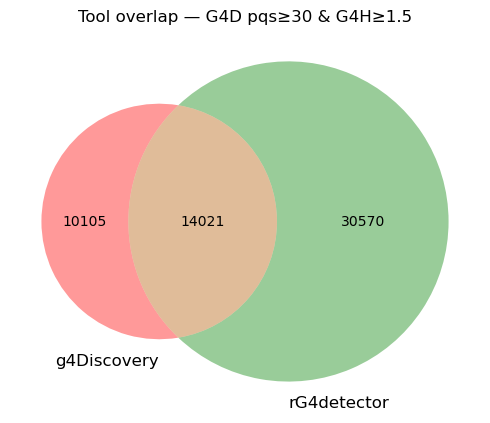

### 4. Coding Breakdown

,Total motifs,With rG4D overlap,Overlap (%)
real,,,
Non-coding,"5,787","1,513",26.1
Protein-coding,"16,815","5,034",29.9


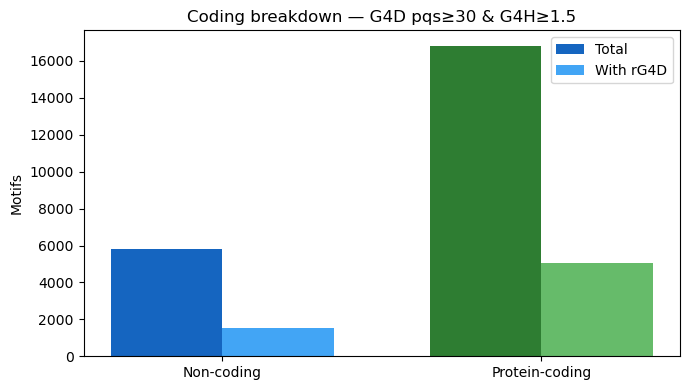

### 5. Length & Position

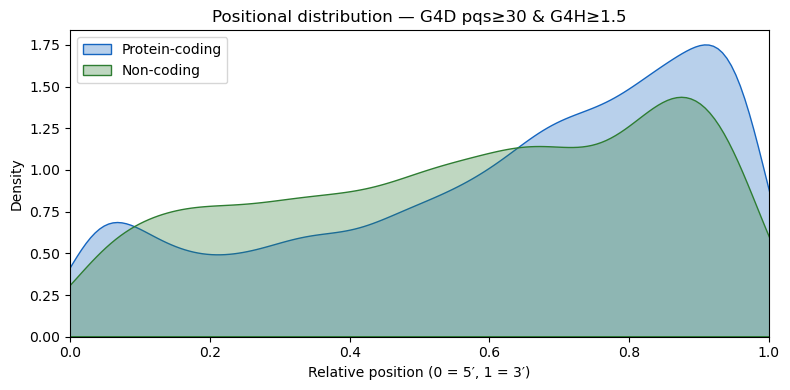

### 6. Score Analysis

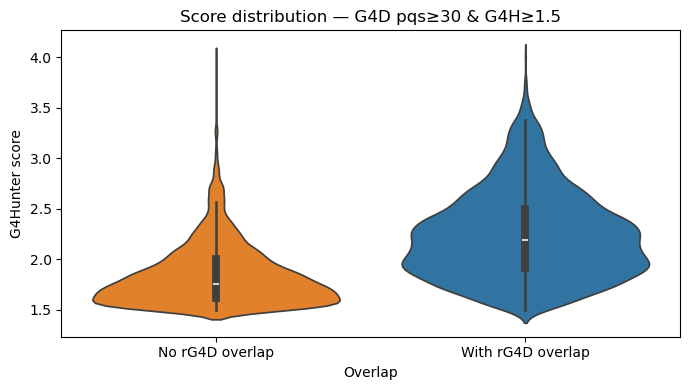

### 7. Statistical Tests

,value
chi2,1.017867e+03
p_chi2,2.348150e-223
cramers_v,9.547995e-02
u_stat,1.577140e+09
p_mwu,1.249014e-209
vda,5.247968e-01
median_coding_per_kb,0.000000e+00
median_lncrna_per_kb,0.000000e+00
n_coding,6.637600e+04
n_lncrna,4.527600e+04


---
## Subset: G4D pqs≥40 & G4H≥1.0
`59,333` motifs

### 3. Aggregate Statistics

,value
total,59333.000000
both,14249.000000
g4d_only,14514.000000
rg4d_only,30570.000000
g4d_total,28763.000000
rg4d_total,44819.000000
g4d_overlap_frac,0.495393
rg4d_overlap_frac,0.317923


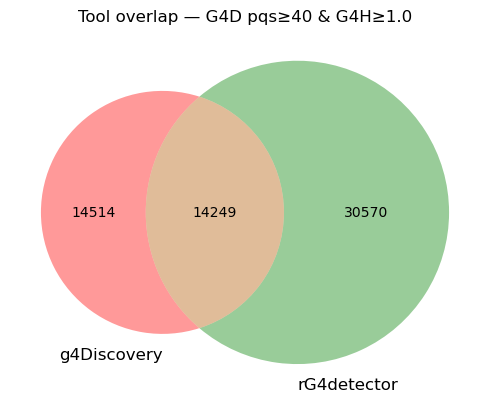

### 4. Coding Breakdown

,Total motifs,With rG4D overlap,Overlap (%)
real,,,
Non-coding,"6,296","1,534",24.4
Protein-coding,"18,664","5,125",27.5


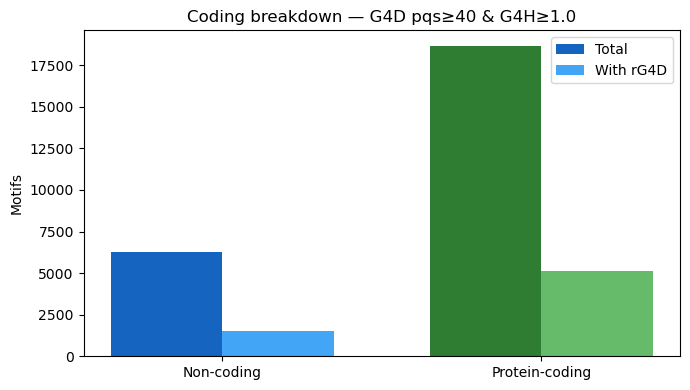

### 5. Length & Position

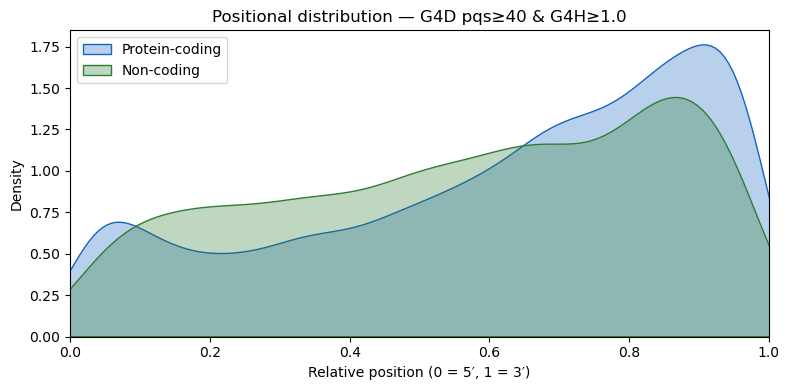

### 6. Score Analysis

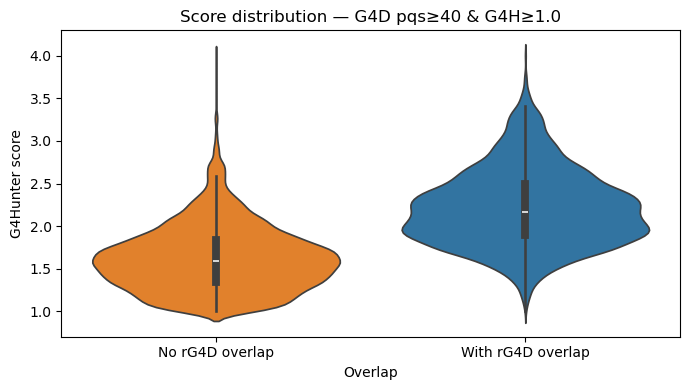

### 7. Statistical Tests

,value
chi2,1.143834e+03
p_chi2,9.815551e-251
cramers_v,1.012158e-01
u_stat,1.586322e+09
p_mwu,5.239803e-234
vda,5.278521e-01
median_coding_per_kb,0.000000e+00
median_lncrna_per_kb,0.000000e+00
n_coding,6.637600e+04
n_lncrna,4.527600e+04


---
## Subset: G4D pqs≥40 & G4H≥1.2
`57,372` motifs

### 3. Aggregate Statistics

,value
total,57372.000000
both,14202.000000
g4d_only,12600.000000
rg4d_only,30570.000000
g4d_total,26802.000000
rg4d_total,44772.000000
g4d_overlap_frac,0.529886
rg4d_overlap_frac,0.317207


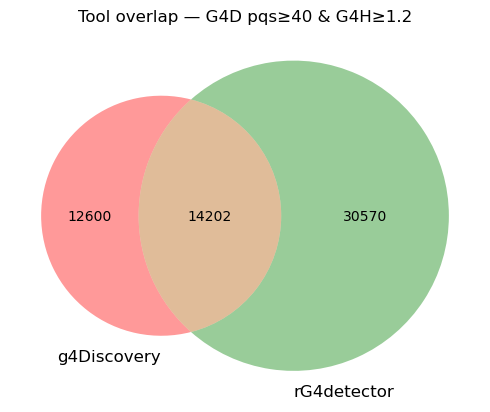

### 4. Coding Breakdown

,Total motifs,With rG4D overlap,Overlap (%)
real,,,
Non-coding,"6,132","1,533",25.0
Protein-coding,"17,822","5,102",28.6


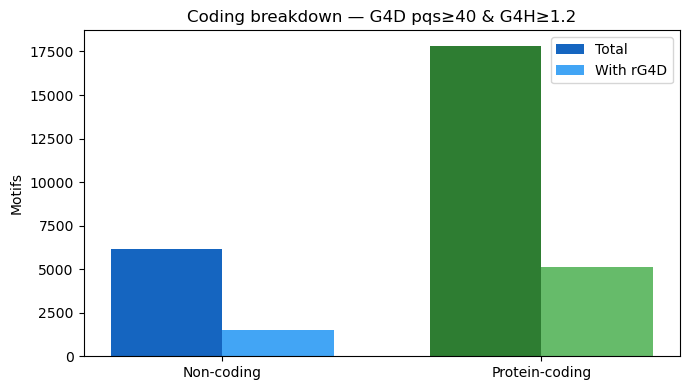

### 5. Length & Position

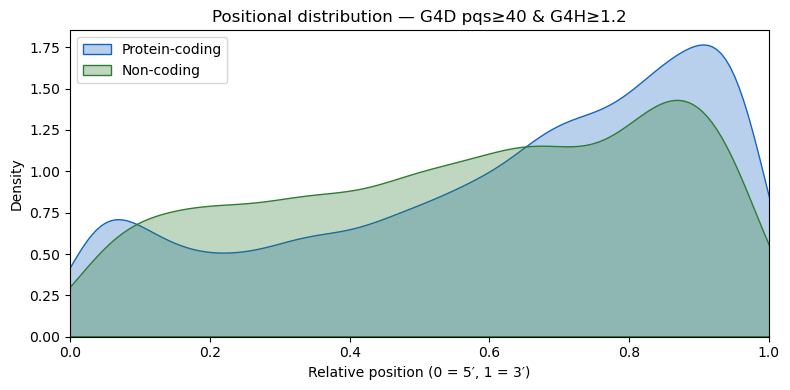

### 6. Score Analysis

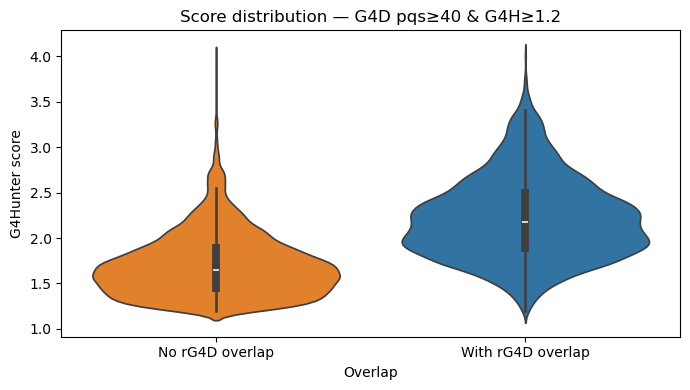

### 7. Statistical Tests

,value
chi2,1.052139e+03
p_chi2,8.344347e-231
cramers_v,9.707409e-02
u_stat,1.581055e+09
p_mwu,8.236670e-216
vda,5.260994e-01
median_coding_per_kb,0.000000e+00
median_lncrna_per_kb,0.000000e+00
n_coding,6.637600e+04
n_lncrna,4.527600e+04


---
## Subset: G4D pqs≥40 & G4H≥1.5
`53,114` motifs

### 3. Aggregate Statistics

,value
total,53114.000000
both,13796.000000
g4d_only,8748.000000
rg4d_only,30570.000000
g4d_total,22544.000000
rg4d_total,44366.000000
g4d_overlap_frac,0.611959
rg4d_overlap_frac,0.310959


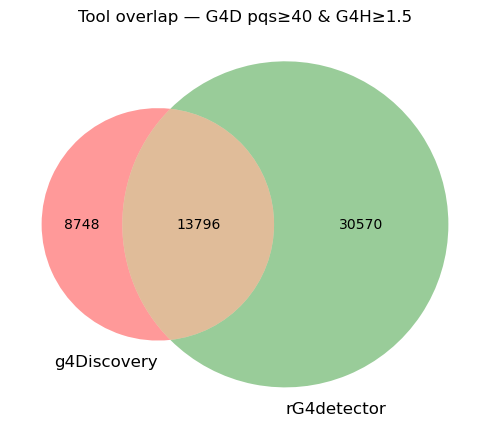

### 4. Coding Breakdown

,Total motifs,With rG4D overlap,Overlap (%)
real,,,
Non-coding,"5,658","1,490",26.3
Protein-coding,"16,161","4,943",30.6


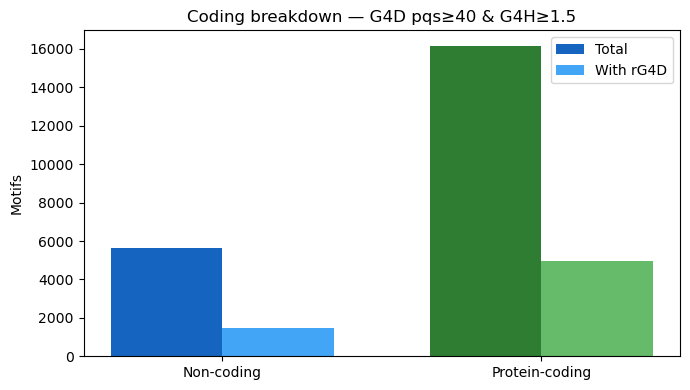

### 5. Length & Position

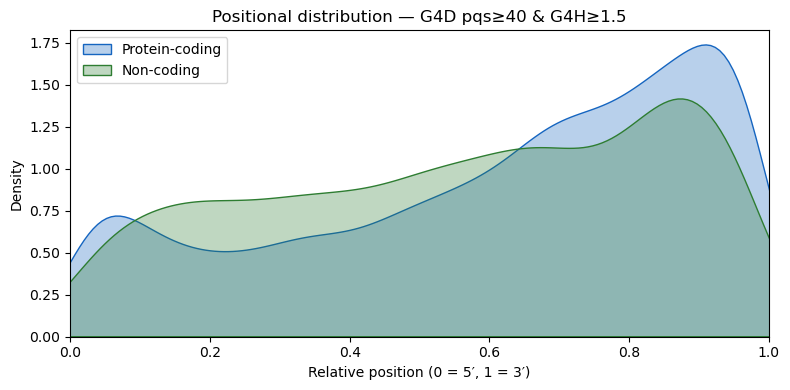

### 6. Score Analysis

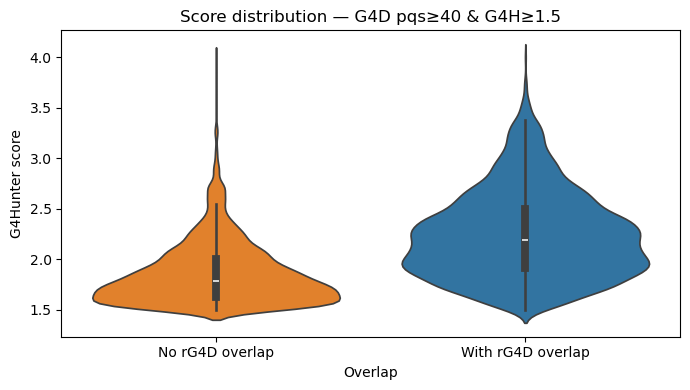

### 7. Statistical Tests

,value
chi2,9.205197e+02
p_chi2,3.397406e-202
cramers_v,9.079946e-02
u_stat,1.571821e+09
p_mwu,2.431308e-190
vda,5.230269e-01
median_coding_per_kb,0.000000e+00
median_lncrna_per_kb,0.000000e+00
n_coding,6.637600e+04
n_lncrna,4.527600e+04



Done. 8 subsets processed.


In [ ]:
all_results = {}
for spec, sdf in subsets:
    result = run_subset_analysis(spec, sdf, coding_ann, length_ann)
    all_results[spec.name] = result
print(f"\nDone. {len(all_results)} subsets processed.")

In [ ]:
from IPython.display import display, Markdown
display(Markdown("---\n# 8. Cross-Subset Comparison"))

comp_df = lib.compare_results(all_results)
display(
    comp_df[[
        "total_motifs", "g4d_total", "rg4d_total", "both", "g4d_overlap_frac",
        "cramers_v", "p_chi2", "vda", "p_mwu",
        "median_coding_per_kb", "median_lncrna_per_kb",
    ]]
    .style
    .format({
        "total_motifs": "{:,}", "g4d_total": "{:,}", "rg4d_total": "{:,}", "both": "{:,}",
        "g4d_overlap_frac": "{:.3f}",
        "cramers_v": "{:.4f}", "p_chi2": "{:.2e}",
        "vda": "{:.4f}", "p_mwu": "{:.2e}",
        "median_coding_per_kb": "{:.4f}", "median_lncrna_per_kb": "{:.4f}",
    })
    .background_gradient(subset=["cramers_v", "vda"], cmap="YlOrRd")
)

---
# 8. Cross-Subset Comparison

,total_motifs,g4d_total,rg4d_total,both,g4d_overlap_frac,cramers_v,p_chi2,vda,p_mwu,median_coding_per_kb,median_lncrna_per_kb
subset,,,,,,,,,,,
Union (all motifs),"61,850","31,280","45,077","14,507",0.464,0.1062,9.19e-276,0.5300,1.42e-256,0.0000,0.0000
rG4D-only motifs,"30,570",0,"30,570",0,0.000,0.0639,2.94e-101,0.5169,3.71e-89,0.0000,0.0000
G4D pqs≥30 & G4H≥1.0,"61,850","31,280","45,077","14,507",0.464,0.1062,9.19e-276,0.5300,1.42e-256,0.0000,0.0000
G4D pqs≥30 & G4H≥1.2,"59,737","29,167","45,029","14,459",0.496,0.1024,1.11e-256,0.5283,3.24e-239,0.0000,0.0000
G4D pqs≥30 & G4H≥1.5,"54,696","24,126","44,591","14,021",0.581,0.0955,2.35e-223,0.5248,1.25e-209,0.0000,0.0000
G4D pqs≥40 & G4H≥1.0,"59,333","28,763","44,819","14,249",0.495,0.1012,9.82e-251,0.5279,5.24e-234,0.0000,0.0000
G4D pqs≥40 & G4H≥1.2,"57,372","26,802","44,772","14,202",0.530,0.0971,8.34e-231,0.5261,8.24e-216,0.0000,0.0000
G4D pqs≥40 & G4H≥1.5,"53,114","22,544","44,366","13,796",0.612,0.0908,3.40e-202,0.5230,2.43e-190,0.0000,0.0000
